In [9]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [10]:
# load returns from previous notebooks
returns = pd.read_csv("../data/sp500_returns_weekly.csv", index_col=0, parse_dates=True)

# validation
print(f" Shape: {returns.shape}")
print(f" Stocks: {returns.shape[1]}")
print(f" Date range: {returns.index[0]} to {returns.index[-1]}")
print(f" Days: {returns.shape[0]}")
print(f" Missing values: {returns.isna().sum().sum()}")


print(f" Mean return: {returns.mean().mean():.4f}")

# store dimensions
n_days, n_stocks = returns.shape

 Shape: (252, 491)
 Stocks: 491
 Date range: 2021-02-21 00:00:00 to 2025-12-14 00:00:00
 Days: 252
 Missing values: 0
 Mean return: 0.0026


In [11]:
# standardize returns because:
# PCA assumes zero mean per feature, needs comparable variance across features
# StandardScaler performs centering: subtract mean return per stock, scaling: divide by standard deviation (volatility)

scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)

print(f"Data standardized:")
print(f"   • Mean: {returns_scaled.mean():.2e} (should be ≈0)")
print(f"   • Std:  {returns_scaled.std():.4f} (should be ≈1)")

Data standardized:
   • Mean: -6.28e-19 (should be ≈0)
   • Std:  1.0000 (should be ≈1)


In [12]:
# fit PCA with all components first
# PCA decomposes the covariance structure of the data into orthogonal directions (principal components), 
# ordered by explained variance
pca_full = PCA()
pca_full.fit(returns_scaled)

# explained variance ratio: 
# - measures how much of the total variance each principal component captures
# - values sum to 1 across all components
explained_variance = pca_full.explained_variance_ratio_

# cumulative explained variance:
# - shows how much total variance is retained when using the first k components
# - used to choose dimensionality reduction threshold
cumulative_variance = np.cumsum(explained_variance)

print(f" PCA fitted with {len(explained_variance)} components")
print(f"\n   Top 3 components:")
print(f"   • PC1: {explained_variance[0]:.2%}")
print(f"   • PC2: {explained_variance[1]:.2%}")
print(f"   • PC3: {explained_variance[2]:.2%}")

 PCA fitted with 252 components

   Top 3 components:
   • PC1: 30.24%
   • PC2: 6.39%
   • PC3: 5.13%


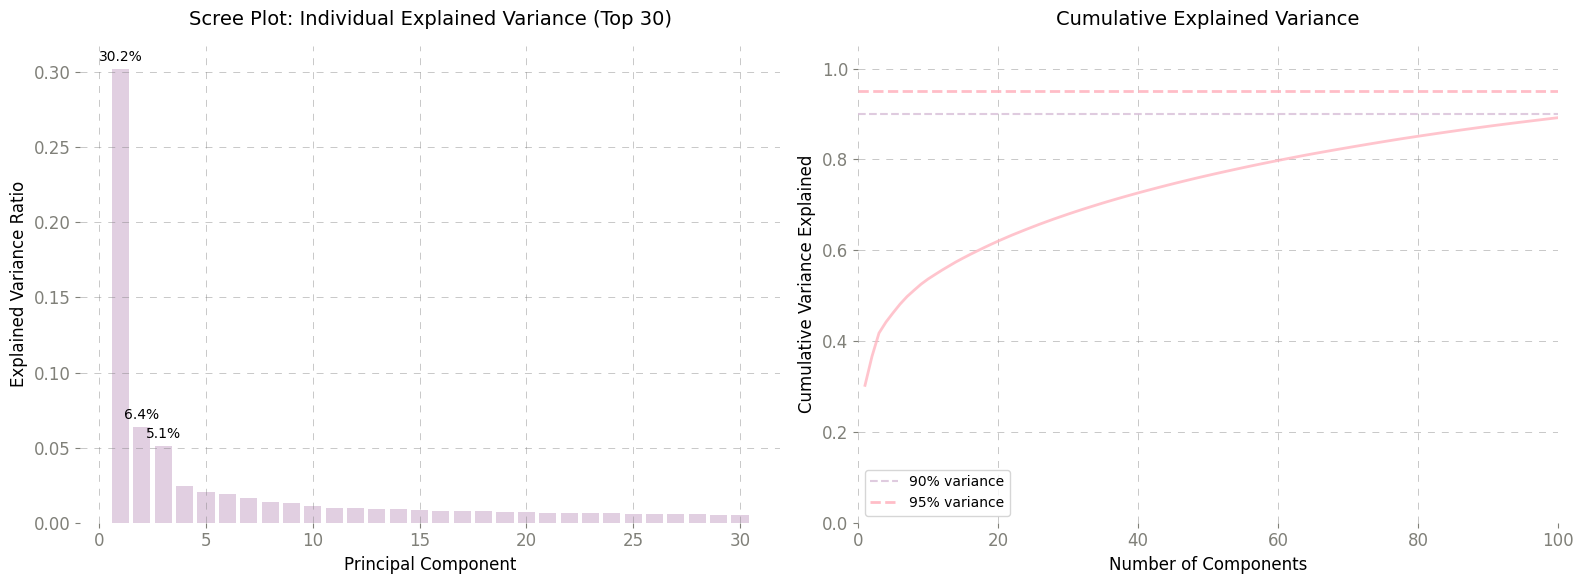

In [13]:
# visualisation left panel: individual explained variance, top 30 PCs

# style
rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size'] = 12

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.bar(
    range(1, 31),
    explained_variance[:30],
    alpha=0.75,
    color='#D8BFD8'
)

ax1.set_title(
    "Scree Plot: Individual Explained Variance (Top 30)",
    fontsize=14,
    pad=15
)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio")

# annotate top 3 components
for i in range(3):
    ax1.text(
        i + 1,
        explained_variance[i] + 0.005,
        f"{explained_variance[i]:.1%}",
        ha="center",
        fontsize=10
    )

# remove spines
for spine in ax1.spines.values():
    spine.set_visible(False)

# grid
ax1.grid(
    True,
    color="gray",
    linestyle=(0, (10, 10)),
    linewidth=0.5,
    alpha=0.6
)

# ticks
ax1.tick_params(colors="#808079")

# right panel: cumulative explained variance
ax2.plot(
    range(1, 101),
    cumulative_variance[:100],
    linewidth=2,
    alpha=0.8,
    color='#FFB6C1'
)

# variance thresholds
ax2.axhline(
    y=0.90,
    linestyle='--',
    linewidth=1.5,
    color='#D8BFD8',
    alpha=0.8,
    label='90% variance'
)

ax2.axhline(
    y=0.95,
    linestyle='--',
    linewidth=2,
    color='#FFB6C1',
    alpha=0.9,
    label='95% variance'
)

# identify component counts
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1

# vertical markers
ax2.axvline(x=n_90, linestyle=':', alpha=0.6, color='#D8BFD8')
ax2.axvline(x=n_95, linestyle=':', alpha=0.6, color='#FFB6C1')

ax2.set_title(
    "Cumulative Explained Variance",
    fontsize=14,
    pad=15
)
ax2.set_xlabel("Number of Components")
ax2.set_ylabel("Cumulative Variance Explained")

ax2.set_ylim(0, 1.05)
ax2.set_xlim(0, 100)

# legend
ax2.legend(fontsize=10)

# remove spines
for spine in ax2.spines.values():
    spine.set_visible(False)

# grid
ax2.grid(
    True,
    color="gray",
    linestyle=(0, (10, 10)),
    linewidth=0.5,
    alpha=0.6
)

# ticks
ax2.tick_params(colors="#808079")

plt.tight_layout()
plt.savefig("../images/pca_scree_plot.png", dpi=300, bbox_inches="tight")
plt.show()


In [14]:
# key findings
# dominant first component (30.2% variance),captures nearly one-third of the total variance
# suggests there's one dominant pattern or underlying factor driving much of the variation
# rapid variance drop -> steep decline after the first component (30.2% → 6.4% → 5.1%)
# subsequent components contribute progressively less information
# top 3 components together explain ~42% of variance, while the remaining 249 components account for the rest


In [15]:
# eigenvalue analysis

# extract eigenvalues from fitted PCA
eigenvalues = pca_full.explained_variance_
explained_variance_ratio = pca_full.explained_variance_ratio_

print("\nEigenvalue statistics:")
print(f"   Total number of eigenvalues: {len(eigenvalues)}")
print(f"   Largest eigenvalue: {eigenvalues[0]:.4f}")
print(f"   Smallest eigenvalue: {eigenvalues[-1]:.6f}")
print(f"   Max / Min ratio: {eigenvalues[0] / eigenvalues[-1]:.0f}x")

print("\nTop 10 eigenvalues:")
for i in range(10):
    print(
        f"   λ{i+1:2d} = {eigenvalues[i]:.4f} "
        f"(explained variance: {explained_variance_ratio[i]:.2%})"
    )



Eigenvalue statistics:
   Total number of eigenvalues: 252
   Largest eigenvalue: 149.0897
   Smallest eigenvalue: 0.000000
   Max / Min ratio: 5070890826810979272075444748288x

Top 10 eigenvalues:
   λ 1 = 149.0897 (explained variance: 30.24%)
   λ 2 = 31.4982 (explained variance: 6.39%)
   λ 3 = 25.2782 (explained variance: 5.13%)
   λ 4 = 11.9525 (explained variance: 2.42%)
   λ 5 = 9.9230 (explained variance: 2.01%)
   λ 6 = 9.4568 (explained variance: 1.92%)
   λ 7 = 8.2138 (explained variance: 1.67%)
   λ 8 = 6.8445 (explained variance: 1.39%)
   λ 9 = 6.6246 (explained variance: 1.34%)
   λ10 = 5.5924 (explained variance: 1.13%)


In [16]:
# key findings:
# extreme max/min eigenvalue ratio indicates some features have near-zero variance
#suggesting: redundant or constant features in the original data
# top 10 components capture the most meaningful patterns and collectively explain ~53% of total variance
# relatively even distribution after the first component (ranging 1-6%) 
# suggests multiple independent patterns rather than one overwhelming factor

# clear evidence of underlying structure
# justification for focusing on top components
# foundation for further feature engineering

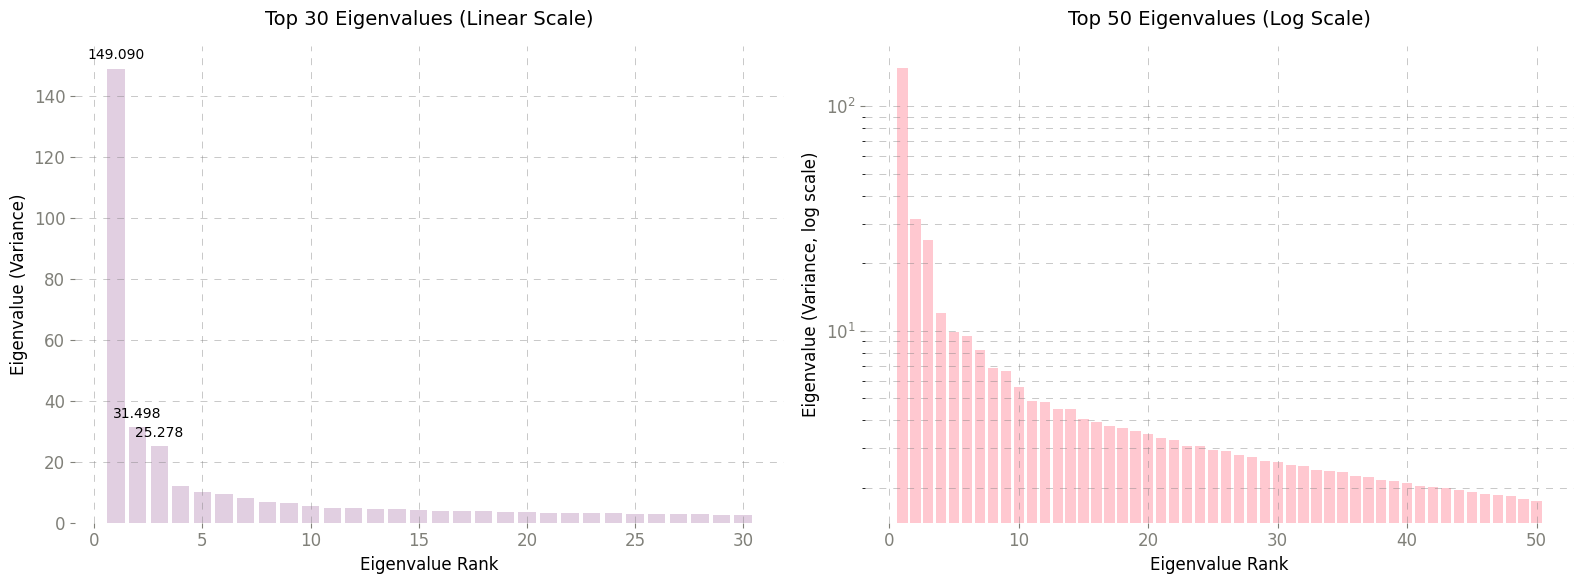

In [17]:
# visualization left: top 30 eigenvalues (linear scale)
#style
rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size'] = 12

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.bar(
    range(1, 31),
    eigenvalues[:30],
    alpha=0.75,
    color='#D8BFD8'
)

ax1.set_title(
    "Top 30 Eigenvalues (Linear Scale)",
    fontsize=14,
    pad=15
)
ax1.set_xlabel("Eigenvalue Rank")
ax1.set_ylabel("Eigenvalue (Variance)")

# annotate first three eigenvalues
for i in range(3):
    ax1.text(
        i + 1,
        eigenvalues[i] + eigenvalues[0] * 0.02,
        f"{eigenvalues[i]:.3f}",
        ha="center",
        fontsize=10
    )

# remove spines
for spine in ax1.spines.values():
    spine.set_visible(False)

# grid
ax1.grid(
    True,
    color="gray",
    linestyle=(0, (10, 10)),
    linewidth=0.5,
    alpha=0.6
)

ax1.tick_params(colors="#808079")

# right: top 50 eigenvalues (log scale)
ax2.bar(
    range(1, 51),
    eigenvalues[:50],
    alpha=0.75,
    color='#FFB6C1'
)

ax2.set_yscale("log")

ax2.set_title(
    "Top 50 Eigenvalues (Log Scale)",
    fontsize=14,
    pad=15
)
ax2.set_xlabel("Eigenvalue Rank")
ax2.set_ylabel("Eigenvalue (Variance, log scale)")

# remove spines
for spine in ax2.spines.values():
    spine.set_visible(False)

# grid
ax2.grid(
    True,
    color="gray",
    linestyle=(0, (10, 10)),
    linewidth=0.5,
    alpha=0.6,
    which="both"
)

ax2.tick_params(colors="#808079")

plt.tight_layout()
plt.savefig("../images/pca_eigenvalue_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [18]:
# key findings
# left (linear): absolute dominance of first eigenvalue (149.09) -> ~5x larger than the second (31.50)
# right panel (log scale): continuous decay pattern -> no sudden "elbow" or plateau, just steady exponential decline
# confirms there's one overwhelmingly dominant pattern, followed by progressively weaker independent patterns


In [19]:
# eigenvectors define the direction of each principal component in the original feature space
# sklearn stores eigenvectors row-wise -> transpose for readability
eigenvectors = pca_full.components_.T  # shape: (n_stocks, n_components)

print("\nEigenvector matrix:")
print(f"   Shape: {eigenvectors.shape}")
print("   Rows   -> stocks")
print("   Columns-> principal components")



Eigenvector matrix:
   Shape: (491, 252)
   Rows   -> stocks
   Columns-> principal components


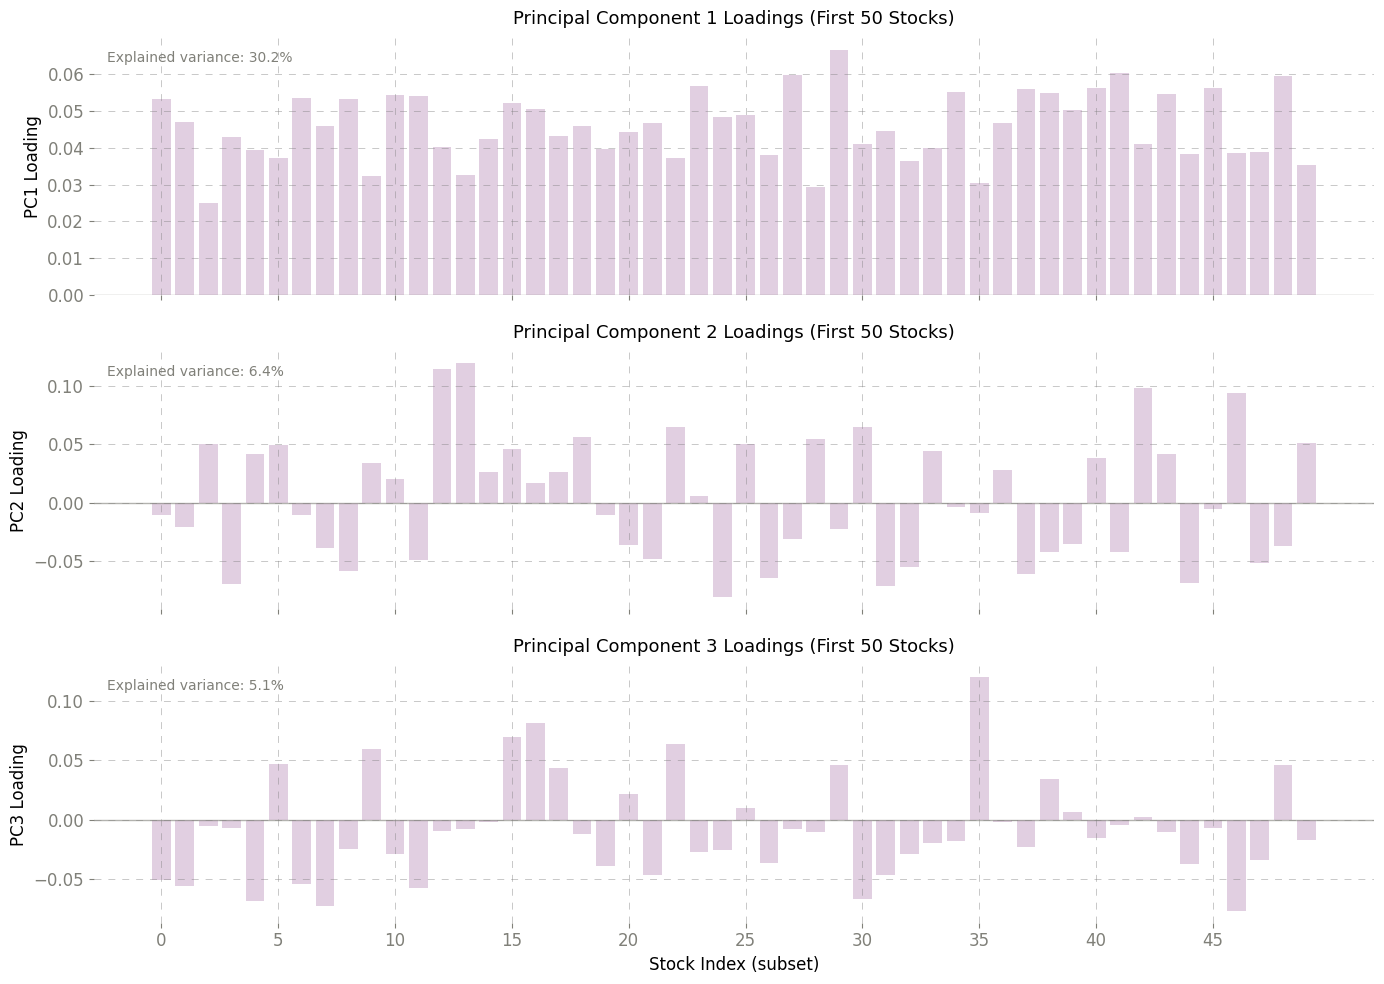

In [20]:
# visualisation PCA
# shows how individual stocks contribute to first three principal components
#style
rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size'] = 12

sample_size = 50
sample_stocks = returns.columns[:sample_size]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, ax in enumerate(axes):
    loadings_i = eigenvectors[:sample_size, i]

    ax.bar(
        range(sample_size),
        loadings_i,
        alpha=0.75,
        color='#D8BFD8'
    )

    ax.axhline(0, linewidth=1, alpha=0.6, color="#808079")

    ax.set_ylabel(f"PC{i+1} Loading")
    ax.set_title(
        f"Principal Component {i+1} Loadings (First {sample_size} Stocks)",
        fontsize=13,
        pad=10
    )

    # variance annotation
    ax.text(
        0.01,
        0.95,
        f"Explained variance: {explained_variance_ratio[i]:.1%}",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        color="#808079"
    )

    # remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # grid
    ax.grid(
        True,
        color="gray",
        linestyle=(0, (10, 10)),
        linewidth=0.5,
        alpha=0.6
    )

    ax.tick_params(colors="#808079")

axes[-1].set_xlabel("Stock Index (subset)")
axes[-1].set_xticks(range(0, sample_size, 5))

plt.tight_layout()
plt.savefig("../images/pca_eigenvector_loadings.png", dpi=300, bbox_inches="tight")
plt.show()


In [21]:
# key findings:
# PC1 (30.2%): all positive loadings, roughly uniform (~0.03-0.06) -> market factor all stocks move together in the same direction
# PC2 (6.4%): mixed positive/negative loadings with clear extremes -> captures stock differentiation, some stocks move opposite to others (likely sector or style contrasts)
# PC3 (5.1%): sparser pattern with both signs -> another independent contrast pattern, possibly capturing different industry groups

# -> PC1 tells "the market went up/down", PC2 and PC3 tell "which stocks outperformed vs. underperformed" (diversification opportunities)

In [22]:
# how many components for 95% variance?
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"Reduced:   {n_components_90} components (90% variance)")

print("="*70)
print("KEY RESULT: DIMENSIONALITY REDUCTION")
print("="*70)
print(f"\nOriginal:  {n_stocks} stocks")
print(f"Reduced:   {n_components_95} components (95% variance)")
print(f"Reduction: {(1 - n_components_95/n_stocks)*100:.1f}%")
print(f"Retained:  {cumulative_variance[n_components_95-1]:.2%}")

print("\nTop 10 components:")
for i in range(10):
    print(f"   PC{i+1:2d}: {explained_variance[i]:6.2%}  "
          f"(cumulative: {cumulative_variance[i]:6.2%})")
print("="*70)

Reduced:   105 components (90% variance)
KEY RESULT: DIMENSIONALITY REDUCTION

Original:  491 stocks
Reduced:   143 components (95% variance)
Reduction: 70.9%
Retained:  95.01%

Top 10 components:
   PC 1: 30.24%  (cumulative: 30.24%)
   PC 2:  6.39%  (cumulative: 36.63%)
   PC 3:  5.13%  (cumulative: 41.76%)
   PC 4:  2.42%  (cumulative: 44.19%)
   PC 5:  2.01%  (cumulative: 46.20%)
   PC 6:  1.92%  (cumulative: 48.12%)
   PC 7:  1.67%  (cumulative: 49.78%)
   PC 8:  1.39%  (cumulative: 51.17%)
   PC 9:  1.34%  (cumulative: 52.52%)
   PC10:  1.13%  (cumulative: 53.65%)


In [23]:
# fit PCA with optimal number of components
# creates PCA model that keeps components enough to capture 95% of variance
pca_optimal = PCA(n_components=n_components_95)
principal_components = pca_optimal.fit_transform(returns_scaled)

# create df
# original 491 stock returns transformed into 143 principal component scores
pc_columns = [f'PC{i+1}' for i in range(n_components_95)]
# convert result into a clean df with dates as rows and PC1, PC2, PC3... as columns
pc_df = pd.DataFrame(principal_components, index=returns.index, columns=pc_columns)

# these PC values are linear combinations of all 491 stock returns, weighted by the loadings

print(f"   • Original: {returns.shape}")
print(f"   • Reduced:  {pc_df.shape}")
print(f"   • Compression: {n_stocks/n_components_95:.1f}x")

pc_df.head()

   • Original: (252, 491)
   • Reduced:  (252, 143)
   • Compression: 3.4x


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC134,PC135,PC136,PC137,PC138,PC139,PC140,PC141,PC142,PC143
Date,,,,,,,,,,,,,,,,,,,,,
2021-02-21,-1.137396,-2.431839,7.464453,-1.495530,3.323133,0.976982,1.310700,-0.498211,-2.200274,-0.060486,...,-0.324085,0.143446,0.693281,1.013766,-0.454916,1.028143,0.227968,0.359931,-1.126557,0.603648
2021-02-28,-9.564514,-5.472137,10.179713,-6.441933,2.225222,-0.335653,-3.719688,-0.153740,-5.316139,3.970022,...,0.415265,0.045575,0.066620,-0.643819,1.150063,-0.835013,0.419138,0.118009,0.623223,0.705380
2021-03-07,9.145518,11.406011,13.688117,-1.390235,0.402493,-2.381586,1.854224,-0.889729,-0.865928,-2.638954,...,-0.422195,-0.370956,-0.000166,0.310317,-0.202570,1.124512,1.499898,0.942474,0.223640,-0.398661
2021-03-14,17.218695,4.789618,0.553301,0.189481,1.837817,3.406419,2.159300,-0.032180,-1.925747,-0.857323,...,-0.319962,1.925210,1.265311,-0.780185,-0.242186,1.179548,2.923874,1.218278,-0.409327,-0.423548
2021-03-21,-4.032737,2.709684,-4.809154,-4.278473,-3.285783,0.256725,4.475914,-0.698968,3.487022,-0.567560,...,0.275603,0.944642,-1.223377,-0.474089,0.647271,0.391766,-1.447330,0.614149,-0.262428,-1.078900


In [24]:
# get loadings (how each stock contributes to each PC)
loadings = pd.DataFrame(
    pca_optimal.components_.T,
    columns=pc_columns,
    index=returns.columns
)

print("Component loadings shape:", loadings.shape)
loadings.head()

Component loadings shape: (491, 143)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC134,PC135,PC136,PC137,PC138,PC139,PC140,PC141,PC142,PC143
A,0.053241,-0.010504,-0.051277,0.004375,-0.076539,-0.036740,-0.080076,-0.020716,0.082903,0.074677,...,0.070729,-0.023551,0.015629,0.058444,-0.048250,-0.017313,-0.073712,0.020518,0.019747,0.005680
AAPL,0.046927,-0.020612,-0.055931,0.010585,-0.006132,-0.015145,0.029486,0.077672,0.021477,-0.095496,...,0.001206,-0.010608,0.014554,0.093424,0.019708,0.014150,-0.112558,0.028244,0.048703,-0.005076
ABBV,0.025084,0.050272,-0.005188,-0.033945,-0.024372,-0.035382,-0.065325,0.030143,0.122001,-0.024998,...,-0.037985,-0.064872,-0.018671,-0.010792,-0.046819,0.023829,0.019840,-0.011786,0.051398,-0.035877
ABNB,0.042839,-0.068828,-0.007135,-0.016145,0.039342,0.065415,-0.005419,0.104183,-0.037602,0.000208,...,-0.067662,-0.093555,-0.020919,0.074201,0.017037,-0.003312,-0.022371,0.034751,0.054599,0.015949
ABT,0.039356,0.041920,-0.068425,-0.036457,0.011620,-0.012248,-0.063675,-0.009426,0.080279,0.001564,...,0.065222,0.109063,-0.044044,-0.036487,0.037662,-0.048249,0.049017,0.056230,-0.003561,0.034356


In [25]:
print("="*70)
print("PC1: MARKET FACTOR")
print(f"   Variance: {explained_variance[0]:.2%}")
print("="*70)

print("\nTop 10 positive contributors:")
print(loadings['PC1'].nlargest(10))

print("\nTop 5 negative contributors:")
print(loadings['PC1'].nsmallest(5))


PC1: MARKET FACTOR
   Variance: 30.24%

Top 10 positive contributors:
BLK     0.068037
AMP     0.066577
DOV     0.066335
ITW     0.064951
MCO     0.063340
PH      0.063332
GS      0.063294
TROW    0.062978
PRU     0.062763
KKR     0.062495
Name: PC1, dtype: float64

Top 5 negative contributors:
GIS    0.013240
DG     0.013400
UNH    0.014774
MOH    0.015615
CPB    0.015716
Name: PC1, dtype: float64


In [26]:
print("="*70)
print("PC2: SECTOR ROTATION")
print(f"   Variance: {explained_variance[1]:.2%}")
print("="*70)

print("\nTop 10 positive contributors:")
print(loadings['PC2'].nlargest(10))

print("\nTop 10 negative contributors:")
print(loadings['PC2'].nsmallest(10))


PC2: SECTOR ROTATION
   Variance: 6.39%

Top 10 positive contributors:
ED      0.134370
DUK     0.131133
SO      0.126643
WEC     0.124504
CMS     0.121810
AEP     0.119252
LNT     0.116058
AEE     0.114713
DTE     0.113086
EVRG    0.111737
Name: PC2, dtype: float64

Top 10 negative contributors:
LRCX   -0.083267
KLAC   -0.081123
AMAT   -0.080463
NVDA   -0.079694
CDNS   -0.079302
NXPI   -0.077503
MPWR   -0.076537
ON     -0.075577
JBL    -0.075227
CRWD   -0.074841
Name: PC2, dtype: float64


In [27]:
print("="*70)
print("PC3: ADDITIONAL FACTOR")
print(f"   Variance: {explained_variance[2]:.2%}")
print("="*70)

print("\nTop 10 positive contributors:")
print(loadings['PC3'].nlargest(10))

print("\nTop 10 negative contributors:")
print(loadings['PC3'].nsmallest(10))

PC3: ADDITIONAL FACTOR
   Variance: 5.13%

Top 10 positive contributors:
XOM     0.134738
COP     0.133155
SLB     0.130143
DVN     0.130105
HAL     0.128752
PSX     0.125912
EOG     0.125740
FANG    0.125600
APA     0.120207
VLO     0.118333
Name: PC3, dtype: float64

Top 10 negative contributors:
ZTS    -0.091935
IDXX   -0.082020
TYL    -0.080383
AWK    -0.077204
MSFT   -0.076858
VRSK   -0.076521
ADBE   -0.073245
CDNS   -0.070789
TMO    -0.070317
EQIX   -0.069743
Name: PC3, dtype: float64


In [28]:
# key findings:
# PC1 financial sector dominates: BLK (BlackRock), GS (Goldman Sachs), AMP (Ameriprise), MCO (Moody's)
# industrials: DOV (Dover), ITW (Illinois Tool Works), PH (Parker-Hannifin)
# asset managers: TROW (T. Rowe Price), KKR, PRU (Prudential)
# "negative" contributors (still positive, just smallest)
# interpretation: systematic market risk -> when the market moves, everything moves together
# cyclical/financial stocks are most sensitive to market movements
# defensive consumer staples are least sensitive (but still positive)
# cannot be diversified away within S&P 500

# PC2: utilities vs. semiconductors (6.39% variance)
# clear sector polarization
# positive (utilities): ED (Con Edison), DUK (Duke Energy), SO (Southern Company), WEC (WEC Energy)
# all regulated utilities with stable dividends
# negative (tech/semiconductors): LRCX (Lam Research), KLAC (KLA), AMAT (Applied Materials), NVDA (Nvidia)
# CDNS (Cadence), NXPI (NXP Semi), CRWD (CrowdStrike)
# interpretation: classic defensive vs. growth rotation
# when utilities outperform (risk-off), semiconductors underperform
# when tech/semis rally (risk-on), utilities lag
# represents investor sentiment shifts between safety and growth


# PC3: energy vs. stable tech (5.13% variance)
# positive (energy): XOM (Exxon), COP (ConocoPhillips), SLB (Schlumberger), DVN (Devon Energy)
# pure oil & gas extraction and services
# negative (quality tech/healthcare): MSFT (Microsoft), ADBE (Adobe), CDNS (Cadence)
# healthcare/software with recurring revenue models
# interpretation: commodity exposure vs. quality growth
# energy stocks move independently based on oil prices
# opposite pole: stable, predictable business models
# captures oil price sensitivity as distinct risk factor


# why this is highly relevant
# 3 distinct risk exposures:
# market beta (PC1)
# growth vs. defensive sentiment (PC2)
# commodity/energy exposure (PC3)

# -> to reduce PC2 exposure: balance utilities with semiconductors
# -> to hedge PC3: combine energy with stable tech
# -> PC1 cannot be hedged within S&P 500


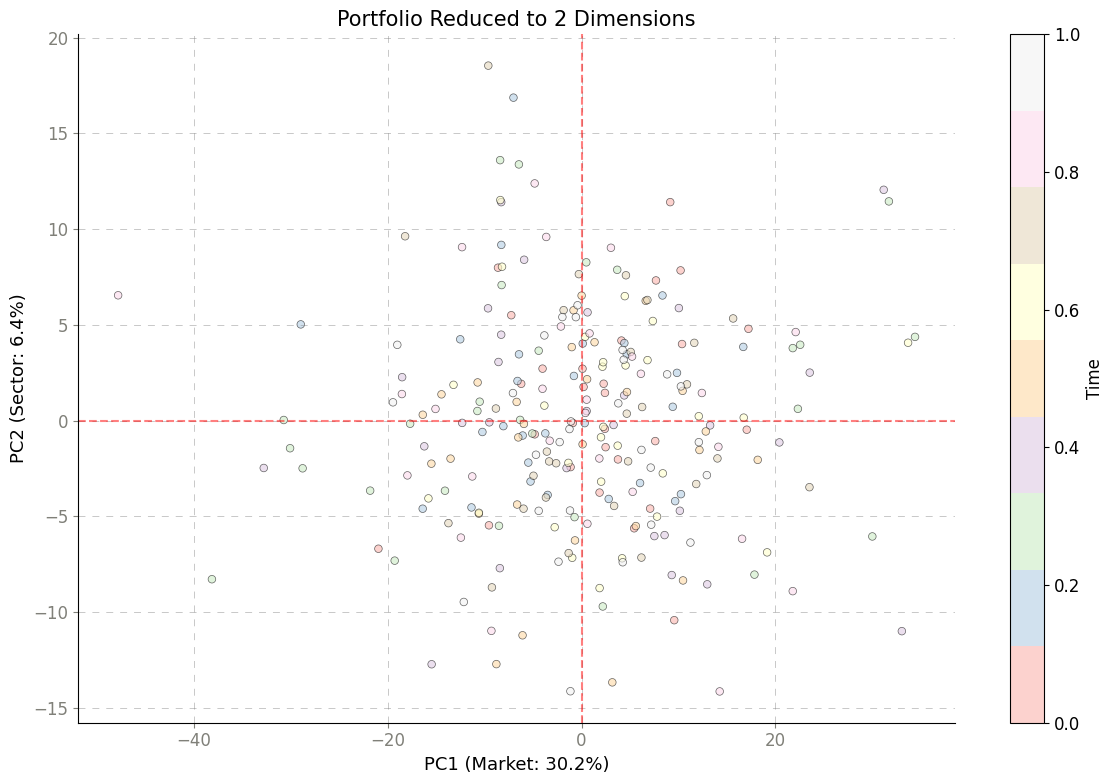

In [37]:
# visualisation scatterplot
# all 252 weeks onto just 2 dimensions (PC1 and PC2) - the two most important factors
# X-axis (PC1): market factor (30.2%), general market up/down movement
# Y-axis (PC2): sector rotation (6.4%), utilities vs. semiconductors
# color gradient: time progression (early weeks = darker, recent weeks = lighter)
# each dot: one week's portfolio position in this 2D "risk space"

rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size'] = 12

plt.figure(figsize=(12, 8))

# create pastel color
colors = np.linspace(0, 1, len(pc_df))
cmap = plt.get_cmap('Pastel1') 

scatter = plt.scatter(
    pc_df['PC1'],
    pc_df['PC2'],
    c=colors,            
    cmap=cmap,
    alpha=0.6,
    s=30,
    edgecolors='black',
    linewidth=0.5
)

plt.xlabel(f'PC1 (Market: {explained_variance[0]:.1%})', fontsize=13)
plt.ylabel(f'PC2 (Sector: {explained_variance[1]:.1%})', fontsize=13)
plt.title('Portfolio Reduced to 2 Dimensions', fontsize=15)

# colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Time')

# grid
plt.grid(
    True,
    color="gray",
    linestyle=(0, (10, 10)),
    linewidth=0.5,
    alpha=0.6
)

# axes 
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)

# spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# tick styling
ax.tick_params(colors="#808079")

plt.tight_layout()
plt.savefig("../images/scatterplot.png", dpi=300, bbox_inches="tight")
plt.show()


In [30]:
# key findings:
# quadrants represent different market regimes:
# top-right (PC1 > 0, PC2 > 0): market rallying + utilities outperforming, risk-on sentiment with defensive positioning
# top-left (PC1 < 0, PC2 > 0): market declining + utilities outperforming, flight to safety
# bottom-right (PC1 > 0, PC2 < 0): market rallying + semiconductors outperforming, strong risk-on, growth-driven rally
# bottom-left (PC1 < 0, PC2 < 0): market declining + semiconductors underperforming, growth stocks leading market down

# wide horizontal spread (PC1: -40 to +30)
# significant market volatility over 5-year period
# large swings between bull and bear sentiment
# major market movements 

# vertical spread (PC2: -15 to +20)
# strong sector rotation dynamics
# periods oscillating between defensive (utilities) and growth (tech/semis)
# more variation on the positive side = more frequent flights to utilities

# cluster around center
# most weeks (high density around origin) show moderate, balanced conditions
# extreme positions are outliers representing crisis/euphoria moments
# if you see clustering by color = regime persistence (market stayed in one mode for extended periods)
# if colors are mixed = frequent regime switching


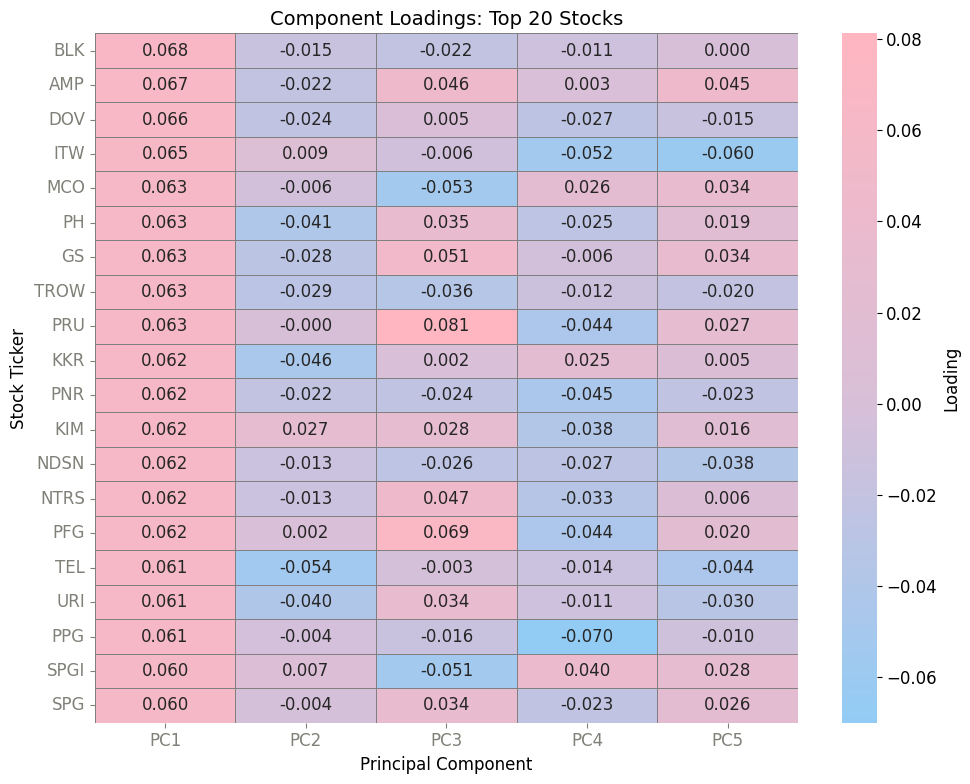

In [31]:
# visualisation heatmap of 20 stocks with highest absolute PC1 loadings
# it shows how they load on the first 5 principal components

rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size'] = 12

# Top 20 stocks by absolute PC1 loading
top_stocks = loadings['PC1'].abs().nlargest(20).index
loadings_subset = loadings.loc[top_stocks, ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']]

plt.figure(figsize=(10, 8))

pastel_cmap = LinearSegmentedColormap.from_list(
    'pastel_gradient', ['#87CEFA', '#D8BFD8', '#FFB6C1'], N=256
)

sns.heatmap(
    loadings_subset,
    cmap=pastel_cmap,
    center=0,
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    cbar_kws={'label': 'Loading'},
    linecolor='gray'
)

plt.title('Component Loadings: Top 20 Stocks', fontsize=14)  # normal weight
plt.xlabel('Principal Component')
plt.ylabel('Stock Ticker')

# Tick styling
ax = plt.gca()
ax.tick_params(colors="#808079")

plt.tight_layout()
plt.show()


In [32]:
# key findings:
# PC1 all move strongly with the market, no blue = no stocks hedge against market movements
# these are high-beta, cyclical stocks that amplify market swings

# PC2 somme negative (blue): KKR (-0.046), TEL (-0.054), URI (-0.040), mostly small values near zero
# market-sensitive stocks are relatively neutral on the sector rotation factor
# neither pure defensive nor pure growth plays

# PC3 Column strong positive: PRU (0.081), PFG (0.069), GS (0.051), AMP (0.046), NTRS (0.047)
# negative: MCO (-0.053), SPGI (-0.051), TROW (-0.036)
# even within cyclical financials, some tilt toward energy-correlated movements while others oppose them

# PC4 & PC5 more noise than signal, values mostly between -0.05 and +0.05
# less clear patterns, explain less variance (2-3% each), less economically meaningful


# portfolio construction:
# for pure market exposure pick stocks with high PC1, low PC2-5
# for diversification avoid clustering these 20 together
# confirms financials/industrials dominate market-sensitive stocks
# no tech stocks in top 20 
# no consumer staples


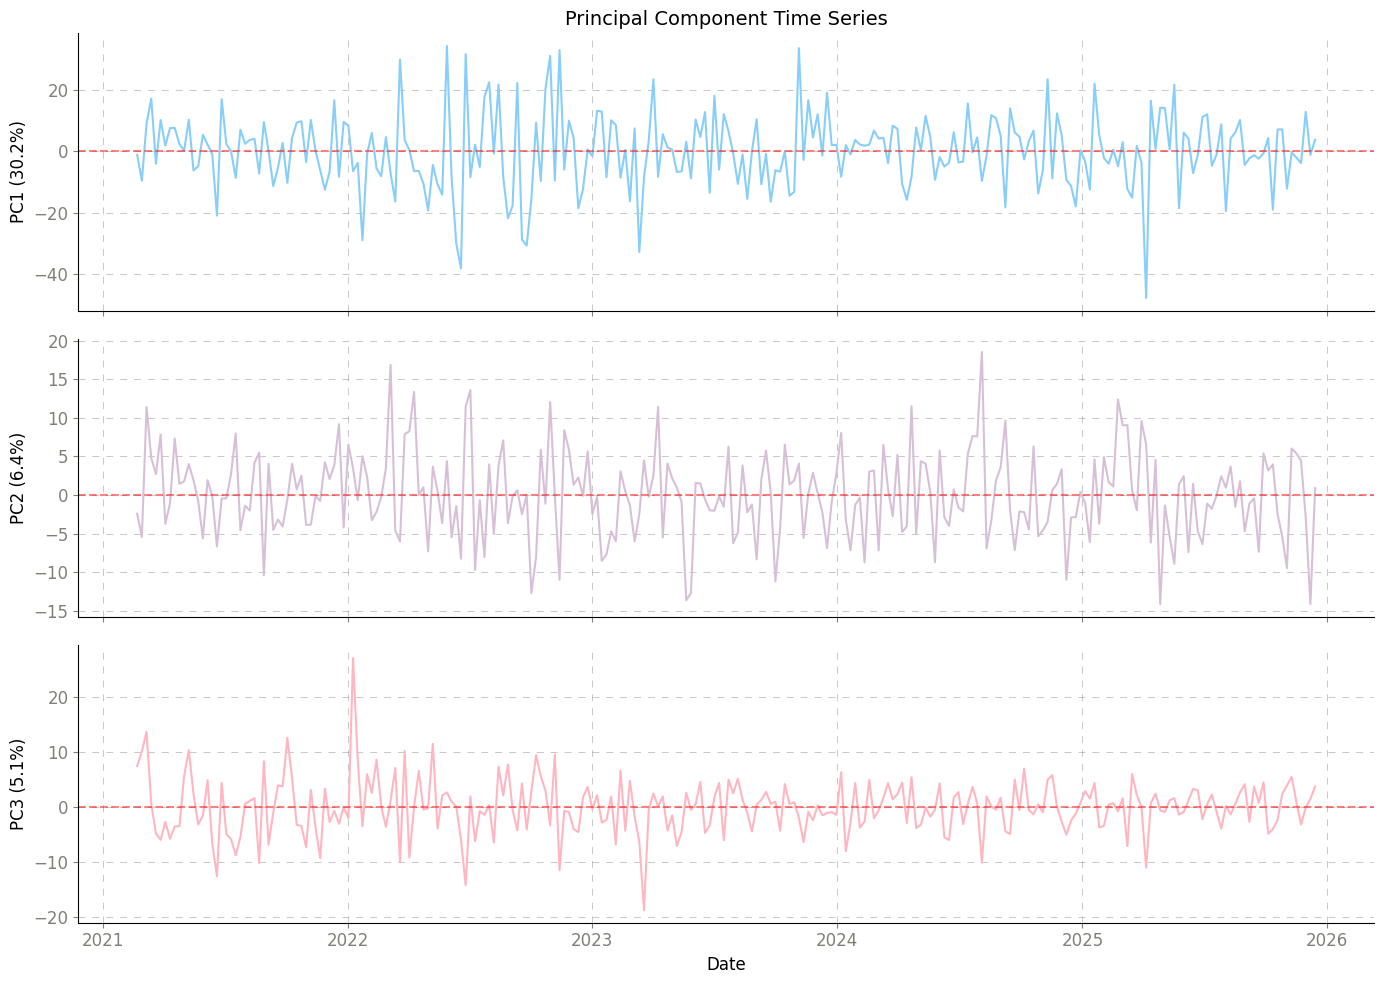

In [33]:
# visualisation values of PC1, PC2, and PC3 over time (2021-2026) 
# showing how these three main risk factors evolved week-by-week throughout the 5-year period

rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size'] = 12

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
colors = ['#87CEFA', '#D8BFD8', '#FFB6C1'] 

# PC1
axes[0].plot(pc_df.index, pc_df['PC1'], linewidth=1.5, color=colors[0])
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_ylabel(f'PC1 ({explained_variance[0]:.1%})')
axes[0].set_title('Principal Component Time Series', fontsize=14)
axes[0].grid(True, color="gray", linestyle=(0,(10,10)), linewidth=0.5, alpha=0.6)

# PC2
axes[1].plot(pc_df.index, pc_df['PC2'], linewidth=1.5, color=colors[1])
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylabel(f'PC2 ({explained_variance[1]:.1%})')
axes[1].grid(True, color="gray", linestyle=(0,(10,10)), linewidth=0.5, alpha=0.6)

# PC3
axes[2].plot(pc_df.index, pc_df['PC3'], linewidth=1.5, color=colors[2])
axes[2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[2].set_ylabel(f'PC3 ({explained_variance[2]:.1%})')
axes[2].set_xlabel('Date')
axes[2].grid(True, color="gray", linestyle=(0,(10,10)), linewidth=0.5, alpha=0.6)

# axes
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors="#808079") 

plt.tight_layout()
plt.savefig("../images/pca_time_series.png", dpi=300, bbox_inches="tight")
plt.show()


In [38]:

# PC1 (market factor 30.2%)
# large spike down (~-40) around mid 2022, major crash (~-40) around early 2025
# persistent positive territory 2023-2024
# high volatility throughout: multiple swings between -20 and +20
# broad market rallies and market selloffs, magnitude shows intensity of movement


# PC2 (sector rotation 6.4%)
# lLess volatile than PC1 (range: -15 to +20)
# sharp positive spike (~+19) mid 2024, several negative dips (-10 to -15) risk-on periods favoring semiconductors
# more mean-reverting than PC1 (oscillates around zero), alternates between risk-on and risk-off regimes


# PC3 (energy Factor 5.1%)
# massive spike (+30) early 2022, (oil/energy shock, russia war)
# recent stability near zero (2024-2026), energy became less volatile/important


In [35]:
# how to identify pc factors:
# examine loadings, look at top positive/negative and identify common characteristics (sector, size, style)

# PC1 = market factor
# evidence: all loadings were positive (0.013-0.068)
# when everything moves together in the same direction = market factor

# PC2 = sector rotation
# top stocks = utilities, bottom = semiconductors
# evidence: clear positive/negative split in loadings
# positive: utilities (ED, DUK, SO, WEC, CMS, AEP...)
# negative: semiconductors (LRCX, KLAC, AMAT, NVDA, CDNS...)

# PC3: top stocks = energy sector (XOM, COP, SLB, etc.)
# evidence: clear energy sector concentration
# positive: XOM, COP, SLB, DVN, HAL, PSX, EOG...
# negative: MSFT, ADBE, ZTS, IDXX, TMO...


In [36]:
print(f"\nRESULTS:")
print(f"   • Dimensionality: {n_stocks} → {n_components_95}")
print(f"   • Reduction: {(1 - n_components_95/n_stocks)*100:.1f}%")
print(f"   • Variance retained: {cumulative_variance[n_components_95-1]:.2%}")

print(f"\nKEY FACTORS (Top 3):")
print(f"   • PC1 ({explained_variance[0]:.1%}): Market factor (broad market movements)")
print(f"   • PC2 ({explained_variance[1]:.1%}): Utilities")
print(f"   • PC3 ({explained_variance[2]:.1%}): Energy sector exposure")

print(f"\nBUSINESS VALUE:")
print(f"   • Monitor {n_components_95} factors instead of {n_stocks} stocks")
print(f"   • {n_stocks/n_components_95:.1f}x dimensionality reduction")
print(f"   • Identify fundamental market drivers")
print(f"   • Faster ML models with 71% fewer features")


RESULTS:
   • Dimensionality: 491 → 143
   • Reduction: 70.9%
   • Variance retained: 95.01%

KEY FACTORS (Top 3):
   • PC1 (30.2%): Market factor (broad market movements)
   • PC2 (6.4%): Utilities
   • PC3 (5.1%): Energy sector exposure

BUSINESS VALUE:
   • Monitor 143 factors instead of 491 stocks
   • 3.4x dimensionality reduction
   • Identify fundamental market drivers
   • Faster ML models with 71% fewer features
